Mood-Based Music Recommendation System

- Project Objective: to build a ML-based music recommendation system that classifies songs by mood using Spotify audio features. After classifying the songs into various mood categories, the system will then recommend songs based on a mood the user inputs.



1. Load and explore the dataset

In [1]:
#import all needed libraries for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

In [2]:
# uploading the CSV file via GitHub to avoid re-uploadng every session
# then, load said data

url = "https://raw.githubusercontent.com/JasmineSharpe/spotify-mood-recommendation-system/refs/heads/main/data/dataset.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# explore dataset using various attributes
print("Shape: ", df.shape)
print("\nColumns: ", df.columns)
print("\nInfo:", df.info)

Shape:  (114000, 21)

Columns:  Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Info: <bound method DataFrame.info of         Unnamed: 0                track_id                 artists  \
0                0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1                1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2                2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3                3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4                4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...            ...                     ...                     ...   
113995      113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996      113996  1hIz5L4IB9hN3WRY

In [4]:
#check for missing values
print("Missing Values: \n", df.isnull().sum())

Missing Values: 
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
#using the following audio features to create various mood categories
total_features = [
    'danceability', 'energy', 'valence', 'tempo',
    'acousticness', 'instrumentalness', 'liveness', 'speechiness'
]

In [7]:
# creating mood labels using core features that define mood best
# valence - measures how positive/happy a song sounds,
# higher values = more positive emoition, lower = sad emotion
# energy - intensity and activity level of a song.
# dancebility - how suitable a song is for dancing, based on rhythm, tempo and
# beat strength.

def assign_mood(row):
    if row['valence'] >= 0.6 and row['energy'] >= 0.6:
        return 'happy'  # high valence, high energy

    elif row['valence'] < 0.4 and row['energy'] < 0.5:
        return 'sad'  # low valence, low energy

    elif row['energy'] >= 0.7 and row['danceability'] >= 0.6:
        return 'energetic' # high energy, high danceability

    elif row['acousticness'] > 0.5 and row['energy'] < 0.5:
        return 'calm' #low-to-moderate intensity
    else:
        return 'neutral'

df['mood'] = df.apply(assign_mood, axis=1)

df[['danceability', 'energy', 'valence', 'tempo', 'mood']].head()

# various thresholds were chosed to separate the high/low values in normalized
# audio features, can be tuned later for optimization

,danceability,energy,valence,tempo,mood
0,0.676,0.4610,0.715,87.917,neutral
1,0.420,0.1660,0.267,77.489,sad
2,0.438,0.3590,0.120,76.332,sad
3,0.266,0.0596,0.143,181.740,sad
4,0.618,0.4430,0.167,119.949,sad


mood
neutral      46841
happy        28872
sad          19588
energetic    10213
calm          8486
Name: count, dtype: int64


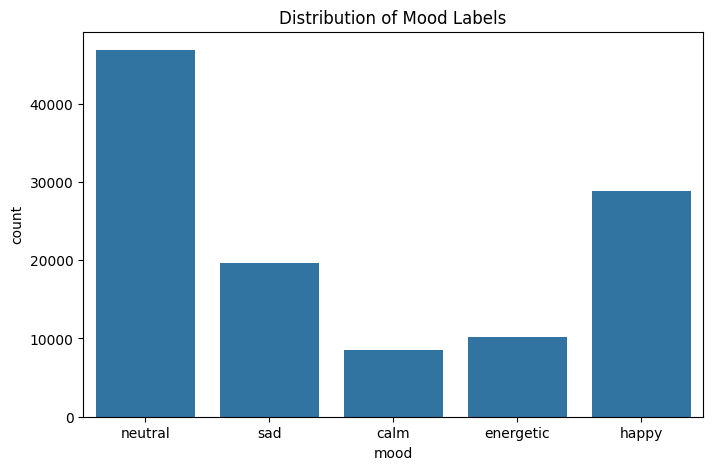

In [8]:
# mood distribution & visualization
print(df['mood'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='mood')
plt.title("Distribution of Mood Labels")
plt.show()

In [9]:
features = ['danceability', 'energy', 'valence', 'tempo']
X = df[features]
y = df['mood']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   danceability  energy  valence    tempo
0         0.676  0.4610    0.715   87.917
1         0.420  0.1660    0.267   77.489
2         0.438  0.3590    0.120   76.332
3         0.266  0.0596    0.143  181.740
4         0.618  0.4430    0.167  119.949

Target:
0    neutral
1        sad
2        sad
3        sad
4        sad
Name: mood, dtype: object


In [10]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (91200, 4)
Testing set: (22800, 4)


In [11]:
# building out preprocessing with pipelines
numeric_features = ['danceability', 'energy', 'valence', 'tempo']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

In [12]:
# logistic regression pipeline
# the task is to predict a mood category w/ numerical values -> classification problem
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)

In [13]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, average='weighted')
log_f1 = f1_score(y_test, y_pred_log, average='weighted')

print("Logistic Regression Performance:")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("F1-score:", log_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance:
Accuracy: 0.8331578947368421
Precision: 0.830981075345345
F1-score: 0.8310086147807708

Classification Report:
              precision    recall  f1-score   support

        calm       0.79      0.71      0.75      1697
   energetic       0.72      0.58      0.64      2043
       happy       0.86      0.88      0.87      5774
     neutral       0.81      0.84      0.82      9368
         sad       0.92      0.93      0.93      3918

    accuracy                           0.83     22800
   macro avg       0.82      0.79      0.80     22800
weighted avg       0.83      0.83      0.83     22800



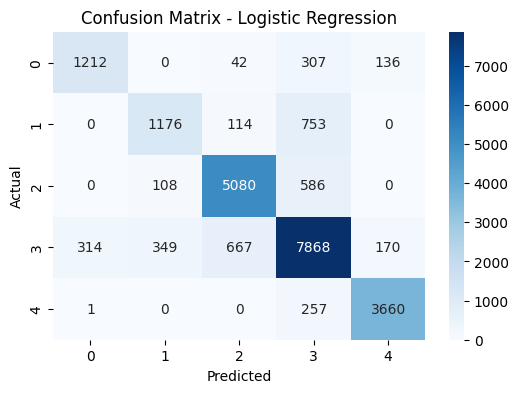

In [35]:
#confusion matrix for visualization
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix illustrates how the model points out differences between mood categories, which highlights any misclassification between similar classes.

In [14]:
# decision tree for next model
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

In [15]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, average='weighted')
tree_f1 = f1_score(y_test, y_pred_tree, average='weighted')

print("Decision Tree Performance:")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("F1-score:", tree_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Performance:
Accuracy: 0.9768859649122807
Precision: 0.976753578910411
F1-score: 0.976815605234567

Classification Report:
              precision    recall  f1-score   support

        calm       0.85      0.84      0.84      1697
   energetic       1.00      1.00      1.00      2043
       happy       1.00      1.00      1.00      5774
     neutral       0.97      0.97      0.97      9368
         sad       1.00      1.00      1.00      3918

    accuracy                           0.98     22800
   macro avg       0.96      0.96      0.96     22800
weighted avg       0.98      0.98      0.98     22800



Because the mood labels were generated using the same features used for training, the models (especially the Decision Tree) are effectively learning deterministic rules rather than discovering new patterns, leading to inflated performance.

In [16]:
# use Random Forest for final model comparison
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [17]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Performance:")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("F1-score:", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.9828508771929825
Precision: 0.9834664675439566
F1-score: 0.9830751320367492

Classification Report:
              precision    recall  f1-score   support

        calm       0.86      0.92      0.89      1697
   energetic       1.00      1.00      1.00      2043
       happy       1.00      1.00      1.00      5774
     neutral       0.98      0.97      0.98      9368
         sad       1.00      1.00      1.00      3918

    accuracy                           0.98     22800
   macro avg       0.97      0.98      0.97     22800
weighted avg       0.98      0.98      0.98     22800



In [18]:
# compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, tree_accuracy, rf_accuracy],
    'Precision': [log_precision, tree_precision, rf_precision],
    'F1-Score': [log_f1, tree_f1, rf_f1]
})

results

,Model,Accuracy,Precision,F1-Score
0,Logistic Regression,0.833158,0.830981,0.831009
1,Decision Tree,0.976886,0.976754,0.976816
2,Random Forest,0.982851,0.983466,0.983075


Although the Decision Tree produced perfect scores across all metrics, it clearly overfits to the data. Random Forest provides a more reliable ensemble-based approach that reduces overfitting. However, Logistic Regression is the better model as the score is more realistic and offers a simpler, interpretable baseline.

In [20]:
# Implementation of simple recommendation system
# first, preview songs in database
df[['track_name', 'artists', 'track_genre', 'mood']].head()

,track_name,artists,track_genre,mood
0,Comedy,Gen Hoshino,acoustic,neutral
1,Ghost - Acoustic,Ben Woodward,acoustic,sad
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,sad
3,Can't Help Falling In Love,Kina Grannis,acoustic,sad
4,Hold On,Chord Overstreet,acoustic,sad


In [30]:
# recommendation function
def recommend_songs_by_mood(selected_mood, num_recommendations=5):
    mood_songs = df[df['mood'] == selected_mood].copy()

    if mood_songs.empty:
        return "No songs found for that mood."

    #recommends songs within a mood that matches audio characteristics
    if selected_mood == 'happy':
        mood_songs = mood_songs.sort_values(by=['valence', 'energy'], ascending=False)
    elif selected_mood == 'sad':
        mood_songs = mood_songs.sort_values(by=['valence', 'energy'], ascending=True)
    elif selected_mood == 'energetic':
        mood_songs = mood_songs.sort_values(by=['energy', 'danceability'], ascending=False)
    elif selected_mood == 'calm':
        mood_songs = mood_songs.sort_values(by=['acousticness', 'energy'], ascending=[False, True])
    elif selected_mood == 'neutral':
        mood_songs = mood_songs.sort_values(by=['valence'], ascending=False)

    return mood_songs[['track_name', 'artists', 'track_genre', 'mood']].head(num_recommendations)

In [33]:
# test the recommendation function
recommend_songs_by_mood('happy', 5)

,track_name,artists,track_genre,mood
1813,The Demander,Victor Rice,afrobeat,happy
87943,Flor de Capomo,Julio Preciado Y Su Banda Perla Del Pacifico,r-n-b,happy
46041,Zuipen,Lawineboys,happy,happy
48741,Zuipen,Lawineboys,hardcore,happy
66064,Roll Your Hands,Debbie Doo,kids,happy


In [32]:
recommend_songs_by_mood('sad', 5)

,track_name,artists,track_genre,mood
64274,The Christmas Song (Chestnuts Roasting On An O...,Nat King Cole;John Legend,jazz,sad
34578,The Sound of Silence,Simon & Garfunkel,folk,sad
93859,Пятеро детей,Татьяна Комова;Георгий Квик,romance,sad
9757,Amor Maior,Jota Quest;Jão,brazil,sad
93503,Monday,Tatiana and Sergey Nikitin,romance,sad


In [26]:
recommend_songs_by_mood('energetic', 5)

,track_name,artists,track_genre,mood
11008,Rolling in the Deep,Adele,british,energetic
20644,Who's Laughing Now - KOLIDESCOPES Remix,Ava Max;KOLIDESCOPES,dance,energetic
43032,Wired,Sonny Fodera;Ella Eyre,groove,energetic
1168,Caminante,Newen Afrobeat,afrobeat,energetic
107638,Everlasting Love,Sandra,synth-pop,energetic


In [27]:
recommend_songs_by_mood('neutral', 5)

,track_name,artists,track_genre,mood
99590,Cocaine,J.J. Cale,singer-songwriter,neutral
6036,Wybór Nie Zakaz,Gruzja,black-metal,neutral
59443,Obsequious Supremacy,Connate Exasperation,iranian,neutral
59676,Act 8 - The Eyes: A Tale of Sight and Shadows,Azooma,iranian,neutral
10603,The Day Is My Enemy,The Prodigy,breakbeat,neutral


In [34]:
# interactivity for demo run
user_mood = input("Enter a mood (happy, sad, energetic, calm): ").lower()

recommendations = recommend_songs_by_mood(user_mood, 5)
print("Recommended Songs:")
recommendations

Enter a mood (happy, sad, energetic, calm): calm
Recommended Songs:


,track_name,artists,track_genre,mood
79886,Konbini,BigRicePiano,piano,calm
75976,"Lo How A Rose, Ere Blooming",Jon Schmidt,new-age,calm
26709,Reindeer(s) Are Better Than People (From 'Froz...,Little Piano Player,disney,calm
26387,"Two Worlds (From ""Tarzan"")",Piano Genie,disney,calm
16725,"Piano Sonata No.14 in C Minor, K. 457: 2c. Ada...",Wolfgang Amadeus Mozart;Claire-Marie Le Guay,classical,calm


This project created a music recommendation system based on mood that used Spotify's audio features. Using a rule-based method that took into account things like valence, energy, danceability, and acousticness, songs were put into mood categories. We used these labeled data to train and test several classification models, such as Decision Tree, Random Forest, and Logistic Regression models.

The results showed that the models could accurately classify song moods, but some models did better than others because the labels were based on rules. A recommendation system  was also made to find songs that fit a user's mood.